# 03. Generator-Evaluator 분리와 두 종류의 검증

> **모델이 자기 자신을 평가**하면 편향이 생겨요. computational verifier(파서)와 inferential verifier(LLM 평가자)를 분리해 검증 루프를 안전하게 짭니다.


> **이 노트북에서 배우는 것**: 모델이 자기 결과를 평가할 때의 함정과, 외부 평가자(Generator-Evaluator 분리) 패턴으로 LangGraph subgraph를 구성하는 법.

> 🧭 **12장 안에서의 위치**: `01-Agent-Testing`이 **외부(개발자)가 에이전트를 검증**하는 단위·통합 테스트를, `02-Agent-Evaluation`이 **LangSmith 데이터셋 기반 오프라인 평가**를 다뤘다면, 이 노트북은 **에이전트 그래프 내부에 evaluator를 실시간 노드로 삽입**해 런타임 자가 수정 루프를 만드는 방법이에요. 즉 "테스트·평가의 원리를 그래프 런타임에 내장"하는 단계예요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있습니다:

1. 자체 평가(self-evaluation)의 편향 문제를 이해하고, 외부 평가자를 분리해야 하는 이유를 설명할 수 있습니다
2. Computational 검증(결정적·고속)과 Inferential 검증(비결정적·LLM 기반)의 차이를 구별하고 적절히 선택할 수 있습니다
3. `ast.parse()`, `json.loads()` 등 코드 수준 verifier를 에이전트 파이프라인에 적용할 수 있습니다
4. LangGraph `StateGraph`로 Generator-Evaluator 패턴 subgraph를 구현하고 자가 수정 루프를 실행할 수 있습니다

## 사전 준비

- `02-Agent-Evaluation.ipynb` 완료 — LLM-as-Judge, agentevals 궤적 평가, LangSmith `client.evaluate()` 파이프라인 숙지
- LangGraph `StateGraph`, `add_conditional_edges` 기본 사용법 (03_Thinking_in_LangGraph 챕터 참고)
- `.env` 파일에 `OPENAI_API_KEY` 설정

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## 1. 자체 평가의 함정 (The Self-Evaluation Trap)

에이전트가 자기 결과를 스스로 평가하게 만들면 편해 보이지만, 실무에서는 조심해야 해요. 같은 모델이 생성자(generator)와 평가자(evaluator)를 동시에 맡으면 두 가지 문제가 발생합니다.

| 문제 | 설명 |
|---|---|
| **확증 편향** | 모델은 자신이 내린 가정을 유지하려는 경향이 있어, 오류를 발견하지 못합니다 |
| **시각적 맹점 공유** | 생성 단계의 지식 한계가 평가 단계에도 그대로 이어집니다 |

Anthropic의 *Building Effective Agents* 글도 에이전트 시스템을 만들 때 단일 거대 프롬프트보다 명확한 workflow, routing, evaluator-optimizer 같은 패턴으로 책임을 나누는 접근을 권장합니다. 이 노트북은 그중 **생성과 평가를 분리하는 최소 패턴**부터 다룹니다.

### 해결책: 외부 평가자 분리

GAN(Generative Adversarial Network)에서 generator와 discriminator를 분리하듯, 에이전트 파이프라인에서도 **생성 노드**와 **평가 노드**를 분리해야 합니다.

```
[Generator Node]  --draft-->  [Evaluator Node]  --score/feedback-->  (조건부 재시도)
```

평가자는 다음 중 하나 이상이어야 합니다:
- **다른 프롬프트**를 가진 동일 모델 (역할 분리만으로도 편향이 줄어듭니다)
- **다른 모델** (완전히 독립된 판단)
- **코드 기반 verifier** (LLM을 사용하지 않는 결정적 검증)


In [2]:
# 자체 평가 vs 외부 평가 비교 데모
# gpt-4o-mini를 사용하여 의도적으로 평범한 요약을 생성한 뒤,
# 동일 모델이 직접 평가할 때와 외부 평가자 프롬프트로 평가할 때의 차이를 비교합니다.

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage

model = init_chat_model("openai:gpt-4o-mini")

# 1단계: 의도적으로 모호한 요약 생성
topic = "양자 컴퓨팅"
mediocre_summary = "양자 컴퓨팅은 양자역학을 이용한 컴퓨팅입니다. 매우 빠릅니다. 미래에 중요할 것입니다."

# === 평가 대상 요약 ===
print(mediocre_summary)
print()

# 2단계: 자체 평가 (self-evaluation) — 동일 역할 프롬프트
self_eval_prompt = [
    SystemMessage(content="당신은 방금 이 요약을 직접 작성한 저자입니다. 이 요약을 평가해주세요."),
    HumanMessage(content=f"다음 요약을 10점 만점으로 평가하고 한 줄 이유를 설명하세요:\n\n{mediocre_summary}"),
]
self_eval_result = model.invoke(self_eval_prompt)
# === 자체 평가 결과 (self-evaluation) ===
print(self_eval_result.content)
print()

# 3단계: 외부 평가자 (external evaluator) — 엄격한 심사 역할 프롬프트
external_eval_prompt = [
    SystemMessage(content=(
        "당신은 독립적인 교육 콘텐츠 심사위원입니다. "
        "다음 기준으로 냉첨하게 평가하세요:\n"
        "- 핵심 개념 정확성 (3점)\n"
        "- 구체적 예시 포함 여부 (3점)\n"
        "- 독자가 실제로 배울 수 있는 정보량 (4점)"
    )),
    HumanMessage(content=f"다음 요약을 10점 만점으로 평가하고 한 줄 이유를 설명하세요:\n\n{mediocre_summary}"),
]
external_eval_result = model.invoke(external_eval_prompt)
# === 외부 평가 결과 (external evaluator) ===
print(external_eval_result.content)

양자 컴퓨팅은 양자역학을 이용한 컴퓨팅입니다. 매우 빠릅니다. 미래에 중요할 것입니다.

이 요약은 4점입니다. 이유는 내용이 너무 간단하고 구체적인 정보가 부족하여 독자가 양자 컴퓨팅에 대한 이해를 제대로 할 수 없기 때문입니다.

점수: 4점

이 요약은 핵심 개념의 정확성은 있지만, 구체적인 예시나 정보량이 부족하여 독자가 실제로 배울 수 있는 내용이 제한적입니다.


## 2. Computational vs Inferential 검증

에이전트의 출력을 검증하는 방법은 크게 두 종류로 나뉩니다.

| 종류 | 특성 | 속도 | 비용 | 예 |
|---|---|---|---|---|
| **Computational** | 결정적(deterministic), 재현 가능 | ms 이하 | 거의 0 | 린터, `ast.parse()`, `json.loads()`, 정규식 |
| **Inferential** | 비결정적(non-deterministic), 확률적 | 수백 ms ~ 수 초 | LLM API 비용 발생 | LLM-as-judge, semantic 유사도 비교 |

Martin Fowler 사이트의 하네스 엔지니어링 글은 코딩 에이전트 주변의 센서와 가이드를 **computational** 과 **inferential** 로 나눠 설명합니다. 이 강의에서는 이를 다음 원칙으로 사용합니다.

> 강의 원칙: **규칙으로 표현할 수 있는 것은 결정론적 검증으로 먼저 막고, 규칙화하기 어려운 의미 판단만 LLM 평가자에게 맡긴다.**

### 실무 선택 기준

```
에이전트 출력에 대해
  → 구문(syntax) 검사가 가능한가?      → Computational verifier 우선
  → 형식(format) 검사가 가능한가?      → Computational verifier 우선
  → 의미(semantics) 판단이 필요한가?   → Inferential verifier 필요
  → 두 텍스트가 "같은 의미"인가?       → Inferential verifier 필요
```

두 종류를 **계층적**으로 사용하는 것이 최선입니다. Computational 검증을 먼저 통과한 출력만 Inferential 검증으로 보내면 비용을 크게 줄일 수 있습니다.

In [3]:
# Computational Verifier 데모
# 에이전트가 Python 코드 또는 JSON을 생성했을 때,
# ast.parse()와 json.loads()로 구문 정합성을 마이크로초 단위로 검증합니다.

import ast
import json
import time


def verify_python_syntax(code: str) -> dict:
    """Python 코드의 구문이 유효한지 ast.parse()로 검증합니다.

    Args:
        code: 에이전트가 생성한 Python 코드 문자열

    Returns:
        {'valid': bool, 'error': str | None, 'elapsed_ms': float}
    """
    start = time.perf_counter()
    try:
        ast.parse(code)
        elapsed = (time.perf_counter() - start) * 1000
        return {"valid": True, "error": None, "elapsed_ms": round(elapsed, 4)}
    except SyntaxError as e:
        elapsed = (time.perf_counter() - start) * 1000
        return {"valid": False, "error": str(e), "elapsed_ms": round(elapsed, 4)}


def verify_json_structure(text: str, required_keys: list[str]) -> dict:
    """에이전트의 텍스트 응답이 유효한 JSON이고 필수 키를 포함하는지 검증합니다.

    Args:
        text: 에이전트가 생성한 JSON 문자열
        required_keys: 반드시 포함되어야 할 키 목록

    Returns:
        {'valid': bool, 'missing_keys': list, 'error': str | None}
    """
    try:
        data = json.loads(text)
    except json.JSONDecodeError as e:
        return {"valid": False, "missing_keys": [], "error": f"JSON 파싱 실패: {e}"}

    missing = [k for k in required_keys if k not in data]
    if missing:
        return {"valid": False, "missing_keys": missing, "error": f"필수 키 누락: {missing}"}

    return {"valid": True, "missing_keys": [], "error": None}


# ------------------------------------------------------------------
# 테스트 실행
# ------------------------------------------------------------------

# === Python 구문 검증 ===

good_code = "def add(a: int, b: int) -> int:\n    return a + b"
bad_code  = "def add(a, b\n    return a + b"   # 의도적 구문 오류

print(f"유효한 코드: {verify_python_syntax(good_code)}")
print(f"오류 코드:   {verify_python_syntax(bad_code)}")
print()

# === JSON 구조 검증 ===

good_json   = json.dumps({"score": 8, "feedback": "명확하고 간결합니다.", "passed": True})
bad_json    = '{"score": 7, "feedback": "좋습니다."}'   # "passed" 키 누락
invalid_json = "score: 7, feedback: 좋습니다"              # JSON 형식 아님

required = ["score", "feedback", "passed"]

print(f"완전한 JSON:  {verify_json_structure(good_json, required)}")
print(f"키 누락 JSON: {verify_json_structure(bad_json, required)}")
print(f"형식 오류:    {verify_json_structure(invalid_json, required)}")


유효한 코드: {'valid': True, 'error': None, 'elapsed_ms': 0.0324}
오류 코드:   {'valid': False, 'error': "'(' was never closed (<unknown>, line 1)", 'elapsed_ms': 0.2694}

완전한 JSON:  {'valid': True, 'missing_keys': [], 'error': None}
키 누락 JSON: {'valid': False, 'missing_keys': ['passed'], 'error': "필수 키 누락: ['passed']"}
형식 오류:    {'valid': False, 'missing_keys': [], 'error': 'JSON 파싱 실패: Expecting value: line 1 column 1 (char 0)'}


In [4]:
# Inferential Verifier 데모
# 에이전트의 자연어 답변을 별도 LLM judge로 채점합니다.
# Pydantic structured output으로 점수를 받아 명확한 숫자 판단을 얻습니다.

from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage


class EvaluationScore(BaseModel):
    """LLM judge의 채점 결과 구조체."""
    accuracy: int = Field(description="사실적 정확성 (0-10)", ge=0, le=10)
    completeness: int = Field(description="내용의 완결성, 빠진 핵심 정보가 없는가 (0-10)", ge=0, le=10)
    relevance: int = Field(description="질문과의 관련성 (0-10)", ge=0, le=10)
    rationale: str = Field(description="채점 근거를 한 줄로 설명")

    @property
    def total(self) -> int:
        return self.accuracy + self.completeness + self.relevance


def inferential_verify(
    question: str,
    answer: str,
    reference: str,
    threshold: int = 21,
) -> dict:
    """LLM judge로 자연어 답변의 품질을 채점합니다.

    Args:
        question: 원래 질문
        answer: 에이전트가 생성한 답변
        reference: 정답 기준 (reference answer)
        threshold: 통과 기준 점수 (30점 만점)

    Returns:
        {'passed': bool, 'score': EvaluationScore, 'total': int}
    """
    judge_model = init_chat_model("openai:gpt-4o-mini").with_structured_output(EvaluationScore)

    messages = [
        SystemMessage(content=(
            "당신은 엄격한 교육 콘텐츠 심사위원입니다. "
            "주어진 질문, 답변, 정답 기준을 보고 답변을 채점하세요. "
            "정확성·완결성·관련성 각 항목을 0-10점으로 채점하고 근거를 설명하세요."
        )),
        HumanMessage(content=(
            f"질문: {question}\n\n"
            f"답변: {answer}\n\n"
            f"정답 기준: {reference}"
        )),
    ]

    score: EvaluationScore = judge_model.invoke(messages)
    return {"passed": score.total >= threshold, "score": score, "total": score.total}


# ------------------------------------------------------------------
# 테스트 실행
# ------------------------------------------------------------------

question = "파이썬의 GIL이 멀티스레딩에 미치는 영향을 설명하세요."
good_answer = (
    "GIL(Global Interpreter Lock)은 CPython에서 한 번에 하나의 스레드만 "
    "Python 바이트코드를 실행하도록 제한하는 뮤텍스입니다. "
    "CPU 바운드 작업에서는 멀티스레딩 성능을 저하시키지만, "
    "I/O 바운드 작업에서는 GIL이 I/O 대기 중 해제되므로 영향이 적습니다."
)
poor_answer = "GIL은 파이썬에 있는 잠금 장치입니다. 멀티스레딩에 영향을 줍니다."
reference = (
    "GIL은 CPython 인터프리터에서 스레드 안전을 위해 사용하는 뮤텍스로, "
    "동시에 하나의 스레드만 Python 객체에 접근할 수 있게 합니다. "
    "CPU 바운드에서 병렬성을 막고, I/O 바운드에서는 영향이 줄어듭니다."
)

# === 우수한 답변 채점 ===
good_result = inferential_verify(question, good_answer, reference)
g = good_result["score"]
print(f"정확성: {g.accuracy}/10, 완결성: {g.completeness}/10, 관련성: {g.relevance}/10")
print(f"합계: {good_result['total']}/30  통과: {good_result['passed']}")
print(f"근거: {g.rationale}")
print()

# === 빈약한 답변 채점 ===
poor_result = inferential_verify(question, poor_answer, reference)
p = poor_result["score"]
print(f"정확성: {p.accuracy}/10, 완결성: {p.completeness}/10, 관련성: {p.relevance}/10")
print(f"합계: {poor_result['total']}/30  통과: {poor_result['passed']}")
print(f"근거: {p.rationale}")


정확성: 10/10, 완결성: 8/10, 관련성: 10/10
합계: 28/30  통과: True
근거: 정답 기준에 따라 GIL이 CPython에서 스레드 안전을 위해 사용하는 뮤텍스라는 기술적 정의와 함께 CPU 바운드 및 I/O 바운드 작업에서의 영향에 관한 설명이 충분히 포함되어 있어 정확성이 높습니다. 그러나 멀티스레딩에의 속도 저하와 같은 구체적인 예시가 없기에 완결성은 다소 떨어집니다. 주제와 관련하여 알맞은 답변을 하고 있어 관련성 점수는 높습니다.

정확성: 4/10, 완결성: 3/10, 관련성: 5/10
합계: 12/30  통과: False
근거: 답변은 GIL이 멀티스레딩에 미치는 영향에 대한 기본적인 설명을 포함하고 있으나, GIL의 구체적인 역할(CPython에서의 뮤텍스 사용 등)과 CPU 바운드 및 I/O 바운드 상황에서의 차이점에 대한 설명이 부족합니다. 따라서 정확성(4점)과 완결성(3점)이 낮고, 적절한 관계성(5점) 덕분에 이 점수를 부여했습니다.


## 3. GAN 패턴: Generator-Evaluator 분리 Subgraph

Anthropic의 *Building Effective Agents* 글은 `evaluator-optimizer`, `orchestrator-workers`처럼 역할을 분리해 더 안정적인 에이전트 workflow를 만드는 패턴을 소개합니다. 이 노트북에서는 그 아이디어를 가장 작은 형태로 줄여, **generator가 만들고 evaluator가 통과/재시도를 결정하는 루프**를 구현합니다.

이를 LangGraph `StateGraph`로 구현하면 다음과 같은 루프 구조가 됩니다:

```
START
  |
  v
[generator]  -- draft -->  [evaluator]
     ^                          |
     |       score < 7          |  score >= 7
     +-- retry <----------------+
                                |
                                v
                               END
```

> 🔗 **Use Case와의 연결**: 이 2-node 루프에 **Planner + Sprint contract** 를 앞에 얹으면 `Planner → Generator → Evaluator` 3-agent 구조로 확장할 수 있어요. 실전 구현은 `11_Use_Cases/09-Three-Agent-Pattern.ipynb`에서 다룹니다. 이 노트북은 **왜 evaluator를 분리해야 하는지·어떤 종류의 검증을 선택해야 하는지** 라는 기초를 다루고, 11/09는 그 기초 위에 Planner·Contract·장시간 실행 전략을 얹어요.

### 핵심 설계 원칙

| 원칙 | 설명 |
|---|---|
| **Context 분리** | generator와 evaluator는 서로 다른 SystemMessage를 사용합니다 |
| **횟수 제한** | `attempts` 카운터로 무한 루프를 방지합니다 |
| **feedback 전달** | evaluator의 피드백을 generator의 다음 프롬프트에 포함해 자가 수정을 구현합니다 |
| **조건부 종료** | `score >= threshold OR attempts >= max_attempts` 이면 END로 이행합니다 |

In [5]:
# GAN Subgraph — State 정의
# TypedDict로 generator-evaluator 루프에서 공유할 상태를 정의합니다.
# (11/09의 HarnessState와 구분하기 위해 GanLoopState로 명명 — 여기선 Planner가 없는 2-node 루프)

from typing import TypedDict


class GanLoopState(TypedDict):
    task: str        # 에이전트에게 주어진 작업 설명
    draft: str       # generator가 생성한 초안
    score: int       # evaluator가 매긴 점수 (0-30)
    feedback: str    # evaluator의 피드백 (다음 generator 호출에 사용)
    attempts: int    # 시도 횟수 (무한 루프 방지용)


# GanLoopState TypedDict 정의 완료
print("필드:", list(GanLoopState.__annotations__.keys()))

필드: ['task', 'draft', 'score', 'feedback', 'attempts']


In [6]:
# GAN Subgraph — generator 및 evaluator 노드 구현

from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field

_model = init_chat_model("openai:gpt-4o-mini")


class DraftScore(BaseModel):
    """evaluator가 generator 초안에 부여하는 점수."""
    score: int = Field(description="총점 (0-30)", ge=0, le=30)
    feedback: str = Field(description="개선을 위한 구체적 피드백 한 줄")


def generator(state: GanLoopState) -> GanLoopState:
    """주어진 task로 한 문단 요약을 생성합니다. 피드백이 있으면 반영합니다."""
    system_msg = SystemMessage(content=(
        "당신은 기술 문서 작성 전문가입니다. "
        "주어진 주제를 한 문단(100-150자)으로 명확하고 간결하게 요약하세요. "
        "전문 용어를 사용하되 일반 독자도 이해할 수 있어야 합니다."
    ))

    if state.get("feedback"):
        user_content = (
            f"주제: {state['task']}\n\n"
            f"이전 초안: {state['draft']}\n\n"
            f"심사위원 피드백: {state['feedback']}\n\n"
            "위 피드백을 반드시 반영하여 개선된 한 문단 요약을 작성하세요."
        )
    else:
        user_content = f"주제: {state['task']}\n\n한 문단으로 요약을 작성하세요."

    result = _model.invoke([system_msg, HumanMessage(content=user_content)])
    current_attempts = state.get("attempts", 0)
    print(f"[generator] 시도 {current_attempts + 1}: {result.content[:60]}...")

    return {
        **state,
        "draft": result.content,
        "attempts": current_attempts + 1,
    }


def evaluator(state: GanLoopState) -> GanLoopState:
    """generator의 초안을 독립적으로 채점하고 피드백을 생성합니다."""
    judge_model = _model.with_structured_output(DraftScore)

    system_msg = SystemMessage(content=(
        "당신은 냉철한 기술 문서 심사위원입니다. "
        "다음 기준으로 요약을 채점하세요:\n"
        "- 명확성: 내용이 이해하기 쉬운가 (0-10)\n"
        "- 간결성: 불필요한 내용이 없는가 (0-10)\n"
        "- 정확성: 사실적으로 올바른가 (0-10)\n"
        "총점과 구체적 개선 피드백을 반환하세요."
    ))

    user_content = (
        f"주제: {state['task']}\n\n"
        f"채점할 요약:\n{state['draft']}"
    )

    result: DraftScore = judge_model.invoke([system_msg, HumanMessage(content=user_content)])
    print(f"[evaluator] 점수: {result.score}/30 | 피드백: {result.feedback[:60]}...")

    return {**state, "score": result.score, "feedback": result.feedback}


# generator / evaluator 노드 함수 정의 완료

In [7]:
# GAN Subgraph — 조건부 엣지 및 StateGraph 컴파일

from langgraph.graph import StateGraph, START, END

SCORE_THRESHOLD = 21   # 30점 만점에서 70% (재작성 기준)
MAX_ATTEMPTS    = 3    # 최대 시도 횟수 (무한 루프 방지)


def should_retry(state: GanLoopState) -> str:
    """점수가 기준 미달이고 시도 횟수가 남아있으면 'retry', 아니면 'done'을 반환합니다."""
    if state["score"] < SCORE_THRESHOLD and state["attempts"] < MAX_ATTEMPTS:
        print(f"[router] 점수 {state['score']} < {SCORE_THRESHOLD} → retry (시도 {state['attempts']}/{MAX_ATTEMPTS})")
        return "retry"
    reason = "통과" if state["score"] >= SCORE_THRESHOLD else f"최대 시도({MAX_ATTEMPTS}회) 초과"
    print(f"[router] {reason} → done")
    return "done"


builder = StateGraph(GanLoopState)

builder.add_node("generator", generator)
builder.add_node("evaluator", evaluator)

builder.add_edge(START, "generator")
builder.add_edge("generator", "evaluator")
builder.add_conditional_edges(
    "evaluator",
    should_retry,
    {"retry": "generator", "done": END},
)

graph = builder.compile()
# GAN subgraph 컴파일 완료
print(f"기준 점수: {SCORE_THRESHOLD}/30 | 최대 시도: {MAX_ATTEMPTS}회")

기준 점수: 21/30 | 최대 시도: 3회


In [8]:
# GAN Subgraph 실행
# "강화 학습의 기본 원리" 주제로 한 문단 요약을 작성하고,
# evaluator가 기준 점수(21/30)를 줄 때까지 반복 개선합니다.

initial_state: GanLoopState = {
    "task": "강화 학습(Reinforcement Learning)의 기본 원리",
    "draft": "",
    "score": 0,
    "feedback": "",
    "attempts": 0,
}

# ============================================================
# GAN Harness 실행 시작
# ============================================================
print()

final_state = graph.invoke(initial_state)

print()
# ============================================================
# 최종 결과
# ============================================================
print(f"총 시도 횟수: {final_state['attempts']}")
print(f"최종 점수: {final_state['score']}/30")
print()
# 최종 요약:
print(final_state["draft"])


[generator] 시도 1: 강화 학습은 에이전트가 환경과 상호작용하며 최적의 행동 전략을 학습하는 기계 학습의 한 분야입니다. 에이전트...
[evaluator] 점수: 28/30 | 피드백: 내용이 전반적으로 명확하게 전달되어 이해하기 쉽고, 강화 학습의 핵심 개념을 잘 설명하고 있습니다. 그러나 ...
[router] 통과 → done

총 시도 횟수: 1
최종 점수: 28/30

강화 학습은 에이전트가 환경과 상호작용하며 최적의 행동 전략을 학습하는 기계 학습의 한 분야입니다. 에이전트는 특정 상태에서 행동을 선택하고, 그 행동의 결과로 보상이나 처벌을 받아 이 정보를 기반으로 행동을 개선하여 장기적인 보상을 극대화하는 것을 목표로 합니다. 이를 통해 에이전트는 탐험(exploration)과 활용(exploitation) 사이의 균형을 맞추며 최적의 정책을 개발합니다.


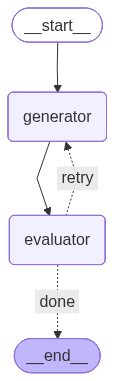

In [9]:
# GAN Subgraph 구조 시각화
# Mermaid 다이어그램으로 노드와 엓지 구조를 확인합니다.

try:
    from IPython.display import Image, display
    img_data = graph.get_graph().draw_mermaid_png()
    display(Image(img_data))
except Exception:
    print(graph.get_graph().draw_ascii())

## 4. 검증과 자가 수정의 결합

이 노트북에서 구현한 패턴은 **외부 검증(Verify) → 피드백 기반 재생성(Correct)** 두 단계가 한 그래프 안에서 맞물려 돌아가는 구조입니다. 검증 단계는 형식·구문 오류를 결정적으로 걸러내고, 그 위에 의미 품질을 LLM judge로 평가합니다. 기준 미달이면 피드백을 다음 generator 호출에 주입해 같은 그래프가 자기 출력을 교정합니다.

### 검증(Verify) 단계에서 배운 것

| 검증 유형 | 구현 | 언제 사용 |
|---|---|---|
| Computational | `ast.parse()`, `json.loads()` | 형식·구문 검사 (항상 먼저) |
| Inferential | `EvaluationScore` + LLM judge | 의미·품질 판단 (Computational 통과 후) |
| 외부 평가자 분리 | 별도 SystemMessage / 별도 모델 | 자체 평가 편향 제거 |

### 자가 수정(Correct) 단계에서 배운 것

| 교정 메커니즘 | 구현 | 효과 |
|---|---|---|
| 피드백 주입 | `feedback` 필드 → generator 프롬프트 | 다음 생성에 구체적 개선 지시 |
| 시도 횟수 제한 | `attempts < MAX_ATTEMPTS` | 무한 루프 방지 |
| 점수 임계값 | `score >= SCORE_THRESHOLD` | 명확한 통과 기준 |

## 정리 및 다음 단계

### 핵심 요약

- **자체 평가 함정**: 동일 모델이 생성과 평가를 동시에 담당하면 확증 편향이 발생합니다. 그래서 생성과 평가 책임을 분리하는 workflow가 중요합니다
- **Computational verifier**: `ast.parse()`, `json.loads()` 같은 결정적 검증을 항상 먼저 적용합니다. ms 이하의 비용으로 형식 오류를 걸러냅니다
- **Inferential verifier**: Pydantic structured output을 활용하면 LLM judge의 채점 결과를 명확한 숫자로 받아 조건 분기에 사용할 수 있습니다
- **Generator-Evaluator 패턴**: `StateGraph`로 generator → evaluator → (조건부) retry 루프를 구성하면 검증과 자가 수정이 자연스럽게 결합됩니다

### 다음 단계 — 이 패턴을 어디서 재사용하나요?

- **`11_Use_Cases/09-Three-Agent-Pattern.ipynb`**: 이 노트북의 2-node 루프(Generator↔Evaluator)에 **Planner + Sprint contract** 를 앞에 붙여 Anthropic의 3-agent 구조를 그대로 구현해요. 여기서 배운 computational/inferential 검증 구분과 self-evaluation trap 인식은 그 노트북의 전제 조건입니다.
- **`02-Agent-Evaluation.ipynb` 복습**: LangSmith `client.evaluate()`로 이 노트북의 verifier를 데이터셋 기반 평가 파이프라인에 통합하는 방법
- **5가지 사고 도구 관점** (`03_Thinking_in_LangGraph/03-Reliability-Engineering`): 이 노트북은 **Verify**(외부 평가) + **Correct**(피드백 기반 재시도) 두 도구를 한 그래프에서 결합한 실전 예시입니다

### 관련 공식 문서

- [LangGraph 그래프 구성](https://docs.langchain.com/oss/python/langgraph/graph-api) — 노드, 엣지, 조건부 분기 레퍼런스
- [LangChain Structured Output](https://docs.langchain.com/oss/python/langchain/structured-output) — Pydantic 기반 구조화 출력 사용법
- [Anthropic: Building Effective Agents](https://www.anthropic.com/research/building-effective-agents) — 에이전트 설계 원칙 원문
- [Martin Fowler site: Harness Engineering](https://martinfowler.com/articles/harness-engineering.html) — computational / inferential 관점 참고

### 다음 노트북 예고

다음 `Part 13 / 01-LangGraph-Platform.ipynb`에서는 **LangGraph Platform으로 에이전트 배포**를 배워요. 지금까지 테스트·평가·검증 기법으로 다져진 에이전트를 `langgraph.json` 설정으로 Agent Server에 올리고, `RemoteGraph` API로 클라이언트에서 호출하는 방법, `langgraph dev`와 `langgraph up`의 차이, LangSmith Studio로 실행을 가시화하는 방법을 다뤄요. 13장 전체가 운영 단계로 넘어가는 출발점이에요.
